<a href="https://colab.research.google.com/github/241541601038-glitch/JALIZ/blob/main/EX02CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded=files.upload()


Saving two.jpg to two.jpg


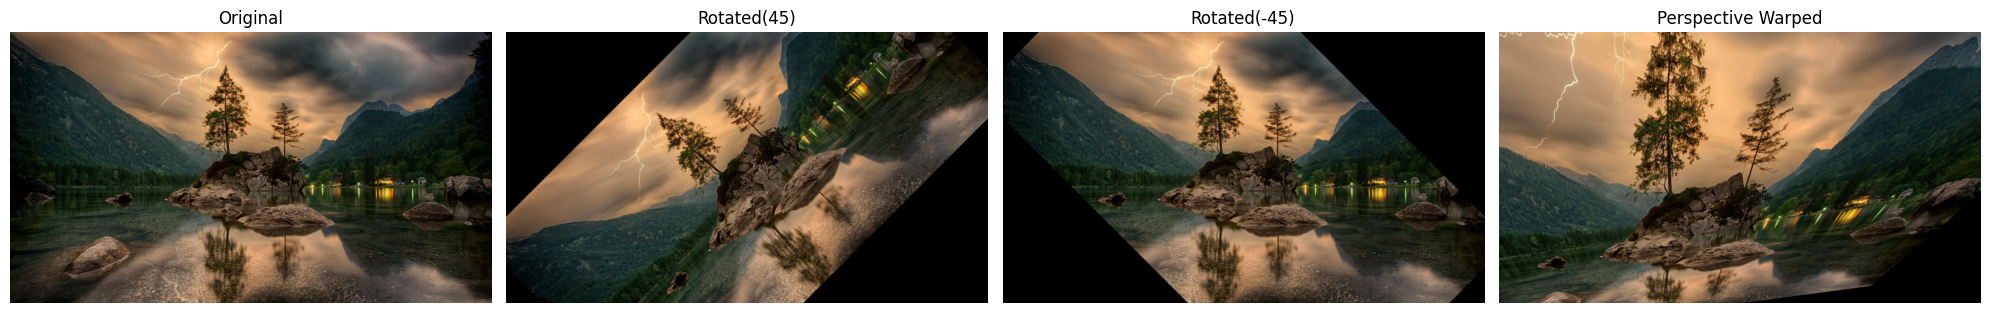

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('/content/two.jpg')
if img is None:
   raise Exception("Image not found")
h,w=img.shape[:2]
center=(w//2,h//2)
M=cv2.getRotationMatrix2D(center,45,1.0)
rotated=cv2.warpAffine(img,M,(w,h))
M_back=cv2.getRotationMatrix2D(center,-45,1.0)
rotated_back=cv2.warpAffine(rotated,M_back,(w,h))
src_points = np.float32([
  [w*0.3,h*0.3],
  [w*0.7,h*0.3],
  [w*0.7,h*0.7],
  [w*0.3,h*0.7]
  ])
dst_points = np.float32([
   [w*0.1,h*0.4],
   [w*0.8,h*0.2],
   [w*0.6,h*0.8],
   [w*0.2,h*0.9]])
warp_matrix = cv2.getPerspectiveTransform(src_points,dst_points)
warped = cv2.warpPerspective(img,warp_matrix,(w,h))
original_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
rotated_rgb=cv2.cvtColor(rotated,cv2.COLOR_BGR2RGB)
back_rotated_rgb=cv2.cvtColor(rotated_back,cv2.COLOR_BGR2RGB)
warped_rgb=cv2.cvtColor(warped,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(20,5))
plt.subplot(1,4,1)
plt.imshow(original_rgb)
plt.title("Original")
plt.axis("off")
plt.subplot(1,4,2)
plt.imshow(rotated_rgb)
plt.title("Rotated(45)")
plt.axis("off")
plt.subplot(1,4,3)
plt.imshow(back_rotated_rgb)
plt.title("Rotated(-45)")
plt.axis("off")
plt.subplot(1,4,4)
plt.imshow(warped_rgb)
plt.title("Perspective Warped")
plt.axis("off")
plt.tight_layout()
plt.show()